# Computation-Through-Dynamics: A Guided Tutorial

This notebook tells one continuous story, using the **3-bit flip-flop (3BFF)** as a running example:

1. What "computation through dynamics" means
2. The 3BFF task, and how **fixed points** describe the *algorithm* the network uses
3. A high-level overview of **task-training** (we use a pretrained model — you will not train one here)
4. **Fixed-point finding** on a pretrained task-trained 3BFF
5. Why we can't observe dynamics directly — we must **infer** them from spikes
6. Using task-trained models to **simulate neural activity**
7. Failure modes of data-driven models: **underfitting** and **invented features**
8. The **input-inference / non-identifiability** problem
9. How **priors** dramatically change the accuracy of inferred dynamics
10. Conclusion

> Every code cell below loads **pretrained models** that ship with the repo, so the notebook runs
> end-to-end without any training. Heavy steps (loading sweeps, computing metrics, finding fixed
> points) are kept modest but real.

## Setup

`HOME_DIR` (from your `.env`) points at the repo root; pretrained models live under
`HOME_DIR/content/trained_models/task-trained/`.

In [1]:
import os
from pathlib import Path

import dotenv
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

dotenv.load_dotenv(override=True)
HOME_DIR = os.environ["HOME_DIR"]
HOME_DIR = HOME_DIR if HOME_DIR.endswith("/") else HOME_DIR + "/"

from ctd.comparison.analysis.tt.tt import Analysis_TT
from ctd.comparison.analysis.dd.dd import Analysis_DD
from ctd.comparison.comparison import Comparison

# Pretrained 3BFF assets curated for this tutorial and tracked via git LFS under
# examples/walkthrough_models/ (see that folder's README). They are a minimal slice of the
# full tt_3bff results: the task-trained teacher, a NODE latent-size sweep (seed=0), and an
# LFADS input-inference sweep (seed=0).
WALK = HOME_DIR + "examples/walkthrough_models/"
PATH_TT = WALK + "tt_3bff/"                 # task-trained 3BFF teacher
PATH_NODE_SWEEP = WALK + "node_sweep/"      # SAE/NODE latent-size sweep
PATH_INPUTINF = WALK + "inputinf_sweep/"    # LFADS input-inference sweep

print("HOME_DIR        =", HOME_DIR)
print("tt_3bff exists  :", Path(PATH_TT + "model.pkl").exists())
print("NODE sweep      :", Path(PATH_NODE_SWEEP).exists())
print("InputInf sweep  :", Path(PATH_INPUTINF).exists())

tt = Analysis_TT(run_name="TT", filepath=PATH_TT, use_train_dm=True)


HOME_DIR        = /Users/chrisversteeg/Documents/Github/ctdTest/ComputationThroughDynamicsToolkit/
tt_3bff exists  : True
NODE sweep      : True
InputInf sweep  : True


/Users/chrisversteeg/Documents/Github/ctdTest/ComputationThroughDynamicsToolkit/ctd/comparison/analysis/tt/tt.py:42: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  self.datamodule = pickle.load(f)


## 1. Introduction to computation-through-dynamics

A recurrent neural network performing a task is a **dynamical system**. Its hidden state
$\mathbf{z}_t$ evolves according to

$$\mathbf{z}_{t+1} = F(\mathbf{z}_t, \mathbf{u}_t),$$

where $\mathbf{u}_t$ are the task inputs and $F$ is the trained update rule. The **computation-through-dynamics (CtD)** view is that the *computation* the network performs is implemented by the
*geometry of this flow* in state space — not by any single neuron.

The vocabulary we use to describe that geometry:

- **Latent state** $\mathbf{z}_t$ — the network's working memory / position in state space.
- **Fixed points** — states where the dynamics (approximately) stop, $F(\mathbf{z}^*, \mathbf{u}) \approx \mathbf{z}^*$. *Stable* fixed points act as memories/attractors; *unstable* ones (saddles) route transitions.
- **Flow field** — how the state moves everywhere else, and how inputs push it between fixed points.

The promise of CtD is that the same analysis works for **two very different kinds of model**:

- **Task-trained (TT)** models — we train an RNN to *do* a task, then dissect its dynamics. The dynamics are ground truth, fully observed.
- **Data-driven (DD)** models — we fit a model to *recorded spikes* and ask what dynamics produced them. Here the dynamics are *inferred*, and may be wrong.

The rest of this notebook builds intuition for both, and for the pitfalls of the inference problem.

## 2. The 3-bit flip-flop, and fixed points as an "algorithm"

The **3-bit flip-flop** is a memory task. There are 3 independent channels; each receives a stream
of $+1$ / $-1$ impulses. Each channel must **remember whether its most recent non-zero pulse was
$+1$ or $-1$** and hold the corresponding bit (1 or 0) on its output until a pulse flips it. A $+1$
pulse when the bit is already 1 does nothing; only a state-changing pulse is "effective."

What is the **algorithm** a network *should* learn? With 3 independent bits there are
$2^3 = 8$ possible memory states. The clean dynamical solution is:

- **8 stable fixed points**, one per bit-pattern, arranged at the corners of a cube.
- **Saddle fixed points** between adjacent corners; an effective input pushes the state across a
  saddle from one stable corner to the neighbor that flips exactly that bit.

So "find the fixed points and their stability" literally recovers the algorithm: the corners are the
stored memories, and the saddle structure is the transition rule. Let's first look at the task I/O on
the pretrained task-trained model.

/Users/chrisversteeg/Documents/Github/ctdTest/ComputationThroughDynamicsToolkit/ctd/comparison/analysis/tt/tt.py:42: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  self.datamodule = pickle.load(f)


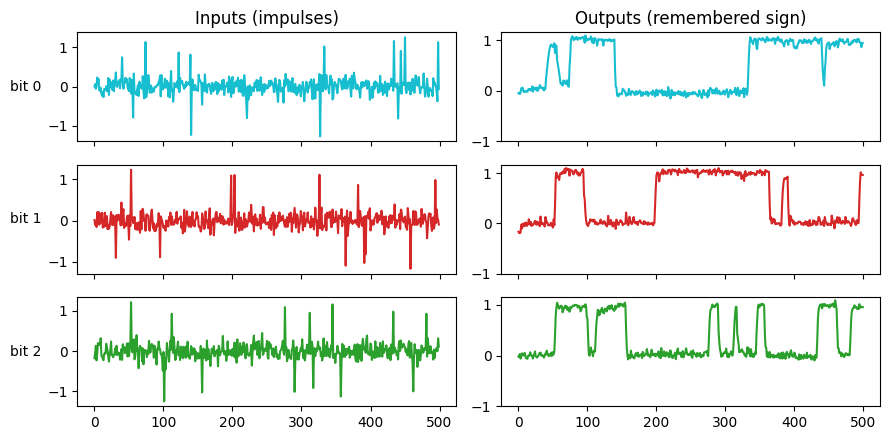

In [2]:
tt = Analysis_TT(run_name="TT", filepath=PATH_TT, use_train_dm=True)

inputs = tt.get_inputs(phase="val")
out = tt.get_model_outputs(phase="val")
controlled = out["controlled"].detach().cpu().numpy()

fig, axes = plt.subplots(3, 2, figsize=(9, 4.5), sharex=True)
colors = ["tab:cyan", "tab:red", "tab:green"]
for i, c in enumerate(colors):
    axes[i, 0].plot(inputs[0, :, i], color=c)
    axes[i, 1].plot(controlled[0, :, i], color=c)
    axes[i, 0].set_ylabel(f"bit {i}", rotation=0, ha="right", va="center")
axes[0, 0].set_title("Inputs (impulses)")
axes[0, 1].set_title("Outputs (remembered sign)")
for ax in axes.ravel():
    ax.set_yticks([-1, 0, 1])
fig.tight_layout()
plt.show()

Because each of the three outputs is a bit in $\{0, 1\}$, the network's **memory state** is a corner
of the unit cube in 3-D output space. Plotting the output trajectories directly shows the
computation: the state sits at a corner (a stored bit-pattern) and jumps along an edge to a
neighboring corner whenever an effective input flips one bit. This is the behavioral shadow of the
fixed-point structure we'll find in Section 4.

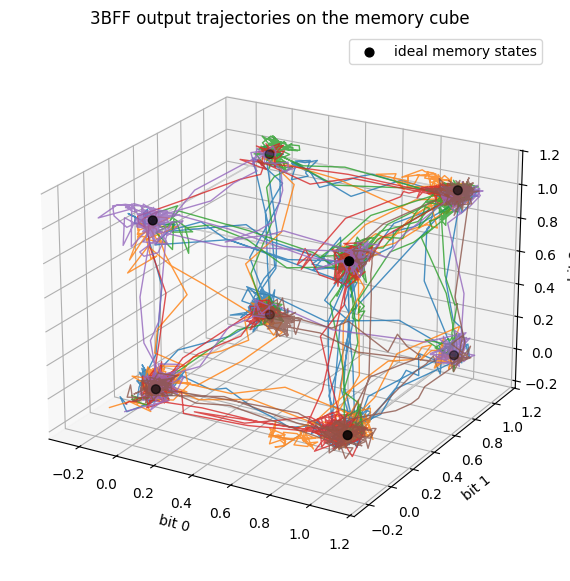

In [3]:
# 3-D view: the 3 outputs traced against each other visit the 8 cube corners.
from itertools import product

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

# Draw the reference cube (the 8 ideal memory states at 0/1 on each bit).
corners = np.array(list(product([0, 1], repeat=3)))
for a in corners:
    for b in corners:
        if np.sum(np.abs(a - b)) == 1:  # edges differ in exactly one bit
            ax.plot(*zip(a, b), color="0.8", lw=1, zorder=1)
ax.scatter(corners[:, 0], corners[:, 1], corners[:, 2],
           color="k", s=40, zorder=3, label="ideal memory states")

# Overlay a few output trajectories hopping between corners.
for i in range(6):
    ax.plot(controlled[i, :, 0], controlled[i, :, 1], controlled[i, :, 2],
            lw=1.0, alpha=0.8)

ax.set_xlabel("bit 0"); ax.set_ylabel("bit 1"); ax.set_zlabel("bit 2")
ax.set_title("3BFF output trajectories on the memory cube")
ax.legend()
ax.view_init(elev=22, azim=-60)
plt.show()

## 3. A high-level overview of task-training (no training required)

A task-trained model is assembled from interchangeable, hydra-configured components:

| Component | Role |
|---|---|
| `task_env` | task logic + trial generation (here: `NBFF` with `n=3` bits) |
| `datamodule` | builds train/val dataloaders from the env |
| `model` | the trainable network (GRU, Vanilla RNN, NODE, ...) |
| `task_wrapper` | runs the train/val loops, optimizers |
| `simulator` | turns trained latents into simulated spikes (Section 6) |

In practice you launch [`examples/run_task_training.py`](run_task_training.py), which uses
`ray.tune` + PyTorch-Lightning to sweep a `SEARCH_SPACE` and saves the trained wrapper to
`content/trained_models/task-trained/<RUN_TAG>/<run_name>/`.

**We do not train a model here** — full runs take minutes-to-hours on a GPU. Instead we load the
**pretrained `tt_3bff`** model (already loaded above as `tt`). The cell below just shows the menu of
tasks and model classes you *could* train.

In [4]:
cfg_root = Path("../ctd/task_modeling/configs")
print("Tasks (env_task):", [p.stem for p in sorted((cfg_root / "env_task").glob("*.yaml"))])
print("TT model classes:", [p.stem for p in sorted((cfg_root / "model").glob("*.yaml"))])
print("\nWe use the pretrained tt_3bff (NBFF task, n=3 bits). No training is run in this notebook.")

Tasks (env_task): ['ChaoticDelayedMatching', 'MultiTask', 'NBFF', 'PhaseCodedMemory', 'RandomTarget']
TT model classes: ['ChaoticRate_RNN', 'DriscollRNN', 'GRU_RNN', 'NODE', 'NODE_ICs', 'NoisyGRU', 'NoisyGRULatentL2', 'OscRNN', 'Vanilla_RNN']

We use the pretrained tt_3bff (NBFF task, n=3 bits). No training is run in this notebook.


## 4. Fixed-point finding on the pretrained task-trained 3BFF

<img src="assets/FPFinder.gif" width="700" alt="Animation of gradient descent finding the zeros of a 1-D speed landscape">

Before running it on the network, here's the idea in one dimension. A fixed point is any state $z$
where the flow stops: $F(z, u) = z$. Rather than solving that directly, fixed-point finding turns it
into an optimization on the **speed** $\lVert dE/dz \rVert = \lVert F(z,u) - z \rVert$ shown above:
starting from many random initial states, gradient descent walks each one downhill until it settles at
a zero of the speed curve. Each converged point is then classified by its local curvature — **stable**
(●, filled), **saddle** (◐, half-filled), or **unstable** (○, open) — exactly the three point types in
the animation.

Now we actually recover the algorithm. We search for fixed points of the **unforced** dynamics
(task inputs clamped to zero — `inputs=torch.zeros(3)`), exactly as in
`make_figure3_task_performance.py` (Panel C). The optimizer minimizes the kinetic energy
$q = \tfrac12\lVert F(\mathbf{z},\mathbf{0}) - \mathbf{z}\rVert^2$ from many random initial
states — the same descent as above, just in the network's full latent space instead of a single scalar
$z$. We keep points below a small `q*` threshold and classify each by its Jacobian.

A trained GRU doesn't place a single mathematically-exact point at each corner — instead each corner
is a **slow region**, so the optimizer returns *many* low-`q*` points clustered around the 8 corners
(plus saddles between them). So read the result from the **geometry** below, not from a literal
count: you should see the stable (green) points group into the 8 cube corners, with unstable (red)
points marking the transitions.

  iter 10000/10000  q=5.38E-06+/-1.46E-05  dq=2.32E-09+/-7.21E-09
  Maximum iteration count reached. Terminating.

Found 2000 unique fixed points.
Decomposing Jacobians in a single batch.
Sorting by Eigenvalue magnitude.
Fixed points below q*<8e-06: 1772  (1653 stable, 119 unstable/saddle)


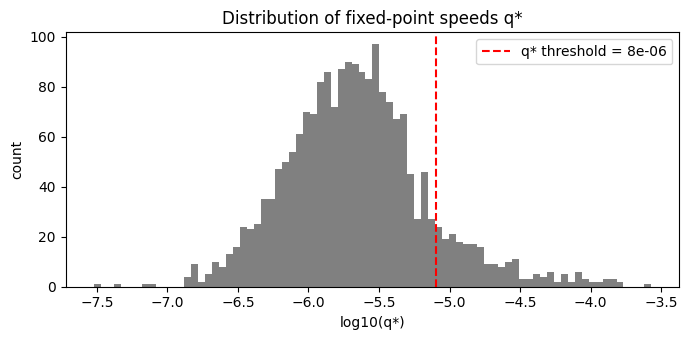

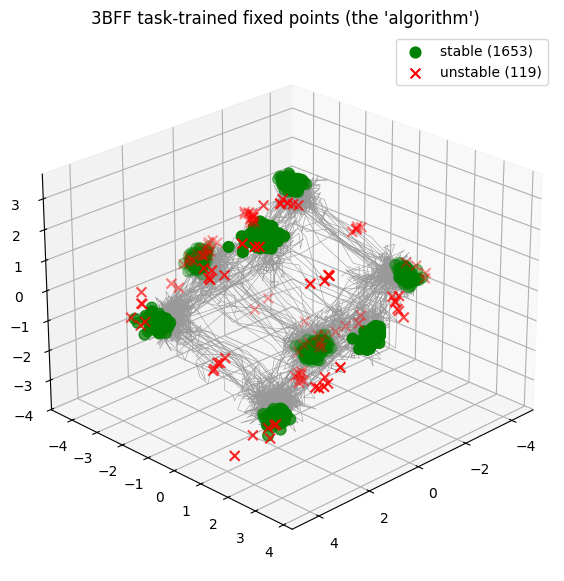

In [5]:
# Fixed points of the autonomous (zero-input) dynamics — mirrors Fig3 panel C.
tt_fps = tt.compute_FPs(
    inputs=torch.zeros(3),
    learning_rate=1e-3,
    noise_scale=0.0,
    n_inits=2000,
    max_iters=10000,
    device="cpu",
)

q_thresh = 8e-6
q_flag = tt_fps.qstar < q_thresh
xstar = tt_fps.xstar[q_flag]
qstar = tt_fps.qstar[q_flag]
stable = tt_fps.is_stable[q_flag] == 1

print(f"Fixed points below q*<{q_thresh:.0e}: {q_flag.sum()}  "
      f"({stable.sum()} stable, {(~stable).sum()} unstable/saddle)")

# q* histogram: the optimizer leaves a cluster of true (low-q*) fixed points and a
# tail of points that never converged. The threshold separates them.
q_all = np.clip(tt_fps.qstar, 1e-16, None)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(np.log10(q_all), bins=80, color="0.5")
ax.axvline(np.log10(q_thresh), color="r", ls="--",
           label=f"q* threshold = {q_thresh:.0e}")
ax.set_xlabel("log10(q*)")
ax.set_ylabel("count")
ax.set_title("Distribution of fixed-point speeds q*")
ax.legend()
fig.tight_layout()
plt.show()

# Project the fixed points (and example latents) to 3 PCs and plot the cube.
pca = PCA(n_components=3).fit(xstar)
x_pca = pca.transform(xstar)
lats = tt.get_latents(phase="val").detach().cpu().numpy()
lats_pca = pca.transform(lats.reshape(-1, lats.shape[-1])).reshape(lats.shape[0], lats.shape[1], 3)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
for i in range(15):
    ax.plot(lats_pca[i, :, 0], lats_pca[i, :, 1], lats_pca[i, :, 2], lw=0.4, color="0.6")
ax.scatter(x_pca[stable, 0], x_pca[stable, 1], x_pca[stable, 2],
           c="g", marker="o", s=60, label=f"stable ({stable.sum()})")
ax.scatter(x_pca[~stable, 0], x_pca[~stable, 1], x_pca[~stable, 2],
           c="r", marker="x", s=50, label=f"unstable ({(~stable).sum()})")
ax.set_title("3BFF task-trained fixed points (the 'algorithm')")
ax.legend()
ax.view_init(elev=25, azim=45)
plt.show()

The stable (green) points cluster at the corners of a cube — one stored memory per 3-bit pattern —
with unstable points marking the transitions between them. (The optimizer returns many near-corner
points rather than 8 exact ones, but they form 8 groups.) **This is the algorithm**: the network
stores each bit-pattern as an attractor and uses effective inputs to hop across saddles to
neighboring corners. Everything that follows asks: *can we recover this picture from spikes alone?*

### 4b. Fixed points under a *held* input `[1, 0, 0]`

Fixed points depend on the input. Above we clamped the input to zero (the autonomous memory
structure). Now hold a **constant `+1` drive on bit 0** (`inputs=torch.tensor([1., 0., 0.])`) while
bits 1 and 2 get no input.

A steady `+1` pulse continuously drives bit 0 toward its **1** state, so the corners with `bit 0 = 0`
are no longer stable — the input pushes the state off them. Expect the stable set to collapse from
the full cube to roughly the **`bit 0 = 1` face** (the 4 corners with bit 0 high), illustrating how
inputs reshape the dynamical landscape — the mechanism the network uses to actually flip bits.

  iter 10000/10000  q=7.72E-05+/-9.47E-05  dq=3.77E-08+/-4.94E-08
  Maximum iteration count reached. Terminating.

Found 2000 unique fixed points.
Decomposing Jacobians in a single batch.
Sorting by Eigenvalue magnitude.
[input=[1,0,0]] below q*<8e-06: 452  (337 stable, 115 unstable)


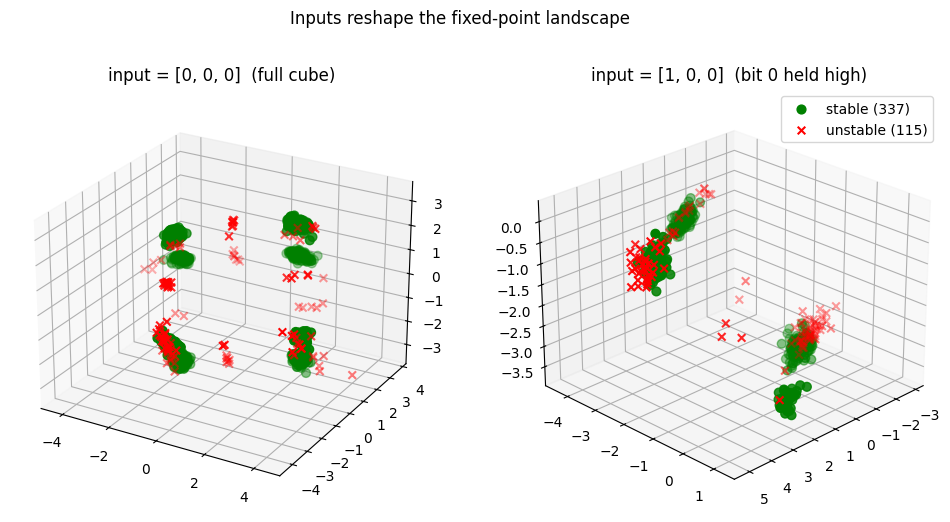

In [6]:
# Fixed points with a constant +1 input on bit 0 (bits 1,2 unforced).
held_input = torch.tensor([1.0, 0.0, 0.0])
tt_fps_in = tt.compute_FPs(
    inputs=held_input,
    learning_rate=1e-3,
    noise_scale=0.0,
    n_inits=2000,
    max_iters=10000,
    device="cpu",
)

q_flag_in = tt_fps_in.qstar < q_thresh          # reuse q_thresh from Section 4
xstar_in = tt_fps_in.xstar[q_flag_in]
stable_in = tt_fps_in.is_stable[q_flag_in] == 1
print(f"[input=[1,0,0]] below q*<{q_thresh:.0e}: {q_flag_in.sum()}  "
      f"({stable_in.sum()} stable, {(~stable_in).sum()} unstable)")

# Project into the SAME PCA space as the zero-input fixed points for a direct comparison.
xstar_in_pca = pca.transform(xstar_in)

fig = plt.figure(figsize=(12, 6))
# Left: zero-input structure (from Section 4), Right: held-input structure.
ax0 = fig.add_subplot(121, projection="3d")
ax0.scatter(x_pca[stable, 0], x_pca[stable, 1], x_pca[stable, 2], c="g", marker="o", s=40)
ax0.scatter(x_pca[~stable, 0], x_pca[~stable, 1], x_pca[~stable, 2], c="r", marker="x", s=30)
ax0.set_title("input = [0, 0, 0]  (full cube)")
ax0.view_init(elev=25, azim=-60)

ax1 = fig.add_subplot(122, projection="3d")
ax1.scatter(xstar_in_pca[stable_in, 0], xstar_in_pca[stable_in, 1], xstar_in_pca[stable_in, 2],
            c="g", marker="o", s=40, label=f"stable ({stable_in.sum()})")
ax1.scatter(xstar_in_pca[~stable_in, 0], xstar_in_pca[~stable_in, 1], xstar_in_pca[~stable_in, 2],
            c="r", marker="x", s=30, label=f"unstable ({(~stable_in).sum()})")
ax1.set_title("input = [1, 0, 0]  (bit 0 held high)")
ax1.legend()
ax1.view_init(elev=25, azim=45)
fig.suptitle("Inputs reshape the fixed-point landscape")
plt.show()

### 4c. Projecting the fixed points through the readout

The PCA views above are convenient but abstract. The network already carries a built-in
**interpretable subspace**: the linear readout `wrapper.model.readout` that maps the 64-D latent
state to the 3 output bits. Pushing the fixed points *through the readout* places them in the exact
memory-cube coordinates from Section 2 — so we can read off *which stored bit-pattern* each stable
fixed point encodes.

This makes the input effect unambiguous: the zero-input fixed points map onto all 8 cube corners,
while the `[1,0,0]` fixed points map onto only the 4 corners with bit 0 high.

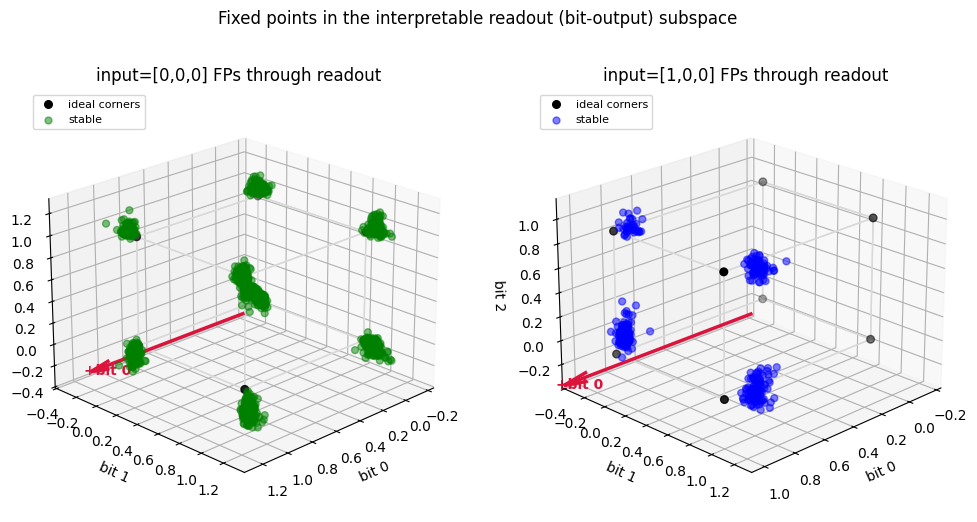

zero-input stable FPs with bit0 > 0.5: 0.42
[1,0,0]  stable FPs with bit0 > 0.5: 1.00


In [7]:
# Project the stable fixed points through the readout into the 3-bit output subspace.
# The readout is linear and the task targets are 0/1, so readout(latent) ~ the [0,1] bit outputs.
SHOW_UNSTABLE = False   # set True to also plot the unstable (saddle) fixed points

readout = tt.wrapper.model.readout

def to_outputs(xstar_np):
    return readout(torch.tensor(xstar_np, dtype=torch.float32)).detach().cpu().numpy()

out_zero = to_outputs(xstar[stable])         # zero-input stable FPs  -> output space
out_held = to_outputs(xstar_in[stable_in])   # [1,0,0] stable FPs     -> output space

# Reference memory cube at 0/1 (the ideal remembered bit-patterns).
cube = np.array(list(product([0, 1], repeat=3)))

conditions = [
    ("input=[0,0,0] FPs through readout", xstar, stable, "g"),
    ("input=[1,0,0] FPs through readout", xstar_in, stable_in, "b"),
]

fig = plt.figure(figsize=(12, 6))
for k, (title, xs, mask, col) in enumerate(conditions):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    for a in cube:
        for b in cube:
            if np.sum(np.abs(a - b)) == 1:      # edges differ in exactly one bit
                ax.plot(*zip(a, b), color="0.85", lw=1, zorder=1)
    ax.scatter(cube[:, 0], cube[:, 1], cube[:, 2], color="k", s=30, zorder=2,
               label="ideal corners")

    stable_out = to_outputs(xs[mask])
    ax.scatter(stable_out[:, 0], stable_out[:, 1], stable_out[:, 2],
               color=col, s=25, alpha=0.5, zorder=3, label="stable")
    if SHOW_UNSTABLE:
        unstable_out = to_outputs(xs[~mask])
        ax.scatter(unstable_out[:, 0], unstable_out[:, 1], unstable_out[:, 2],
                   color="r", marker="x", s=25, alpha=0.5, zorder=3, label="unstable")

    # Arrow marking the +bit-0 direction — the axis the [1,0,0] input drives toward.
    ax.quiver(-0.15, -0.3, -0.3, 1.3, 0, 0, color="crimson", lw=2.5,
              arrow_length_ratio=0.12, zorder=5)
    ax.text(1.2, -0.3, -0.3, "+bit 0", color="crimson", fontsize=10, weight="bold")
    ax.set_xlabel("bit 0"); ax.set_ylabel("bit 1"); ax.set_zlabel("bit 2")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    ax.view_init(elev=22, azim=45)
fig.suptitle("Fixed points in the interpretable readout (bit-output) subspace")
plt.show()

# Quantify: fraction of each stable set on the bit0-high (near 1) side.
print(f"zero-input stable FPs with bit0 > 0.5: {(out_zero[:, 0] > 0.5).mean():.2f}")
print(f"[1,0,0]  stable FPs with bit0 > 0.5: {(out_held[:, 0] > 0.5).mean():.2f}")

## 5. We don't get the dynamics for free — we infer them from spikes

In a real experiment we never observe $\mathbf{z}_t$ or its flow field. We observe **spikes**: noisy,
discrete samples from neurons whose firing rates are some readout of the latent state. The generative
chain is

$$\mathbf{z}_t \;\xrightarrow{\text{readout}}\; \text{rates } \boldsymbol{\lambda}_t \;\xrightarrow{\text{Poisson}}\; \text{spikes } \mathbf{y}_t .$$

The scientific goal is to **invert** this chain: from $\mathbf{y}_t$ alone, recover a latent dynamical
system whose fixed-point structure matches the true one in Section 4. A **data-driven (DD)** model
(e.g. LFADS or other sequential autoencoder) does exactly this — it fits spikes and exposes inferred
latents we can then run fixed-point finding on.

The catch, which the rest of the notebook is about: **many different inferred dynamical systems can
explain the same spikes equally well.** Some recover the cube; others don't.

## 6. Simulating neural activity from a task-trained model

To study inference with ground truth in hand, we use the TT model as a **ground-truth dynamical system**: its `simulator`
maps trained latents → firing rates → sampled spikes, and writes them to
`content/datasets/dd/`. A DD model is then trained on those spikes, and because we *know* the true
latents/rates, we can score how well it recovers them.

Rather than re-simulate here, we load one already-trained DD model (from a sweep using a neural ODE-based DD model) — its
datamodule carries the simulated spikes and the true rates. Below we show, for the same trial, the
**true firing rates** the teacher produced and the **observed spikes** a DD model actually sees.

/Users/chrisversteeg/Documents/Github/ctdTest/ComputationThroughDynamicsToolkit/ctd/comparison/analysis/dd/dd.py:53: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  self.datamodule = CPU_Unpickler(f).load()


true_rates: (200, 500, 60)  spikes: (200, 500, 60) (trials, time, neurons)


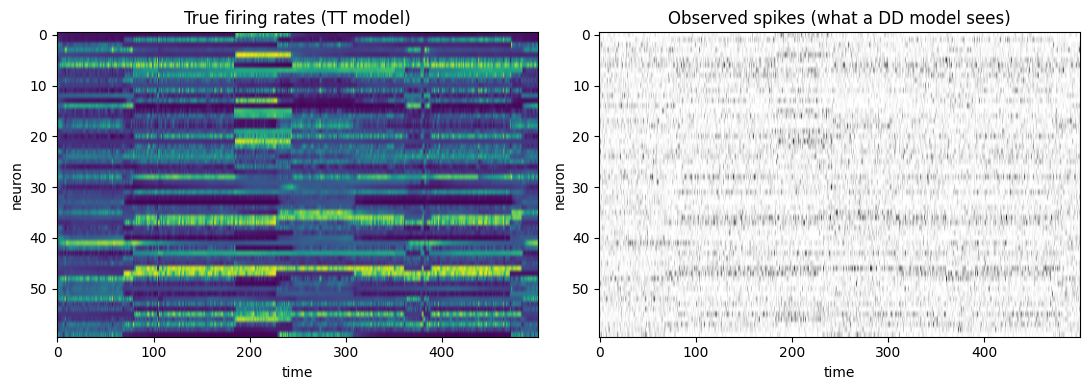

In [8]:
# Load a single data-driven model just to access the simulated dataset it was trained on.
sub0 = sorted(p for p in Path(PATH_NODE_SWEEP).glob("*latent_size=8*seed=0*") if p.is_dir())
dd_demo = Analysis_DD.create(run_name="demo", filepath=str(sub0[0]) + "/", model_type="SAE")

true_rates = dd_demo.get_true_rates(phase="val").detach().cpu().numpy()
spikes = dd_demo.get_spiking(phase="val").detach().cpu().numpy()
print("true_rates:", true_rates.shape, " spikes:", spikes.shape, "(trials, time, neurons)")

trial = 0
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(true_rates[trial].T, aspect="auto", cmap="viridis")
axes[0].set_title("True firing rates (TT model)")
axes[0].set_xlabel("time"); axes[0].set_ylabel("neuron")
axes[1].imshow(spikes[trial].T, aspect="auto", cmap="Greys")
axes[1].set_title("Observed spikes (what a DD model sees)")
axes[1].set_xlabel("time"); axes[1].set_ylabel("neuron")
fig.tight_layout()
plt.show()

## 7. Failure modes of data-driven models: underfitting & invented features

A DD model can fail in (at least) two opposite directions:

- **Underfitting** — too little capacity: it can't represent the dynamics, so
  the firing rates are reconstructed poorly. This can be caused by dynamics models that are insufficiently expressive (e.g., trying to approximate non-linear dynamics with a linear dynamical system), insufficient training time, too few latent dimensions, etc.
- **Invented features** — too *much* capacity: it reconstructs the spikes well but
  spends the extra dimensions on **spurious structure** that are not present in the true system.

A useful way to see both failures at once is to plot **reconstruction (x) vs. simplicity (y)**. A good
model lives in the upper-right: it reconstructs the data *and* stays simple/faithful. "Invented
features" models drift to the lower-right — good reconstruction, poor simplicity.

For this tutorial, we show two ways to quantify performance with these metrics. One method requires ground-truth, while the other doesn't.

- **Ground-truth metrics** (need the true TT model): `rate_r2` (reconstruction of true rates) vs
  `state_r2` (do the inferred latents linearly match the true ones?).
- **Non-ground-truth metrics** (computable from spikes alone): `co-bps` (held-out-neuron
  reconstruction) vs `cycle_con` (self-consistency of the latent↔rate mapping).

The point: even without ground truth, the recon-vs-simplicity trade-off can help identify models that underfit or invent features.

<img src="assets/FailureModes.png" width="900" alt="Three failure modes of data-driven models: underfitting, invented features, and dynamical misattribution">

Three ways a data-driven model's inferred latents ($\hat z$) can diverge from the true latents ($z$),
all while looking plausible from the outside:

- **F. Underfitting** — the model lacks the capacity (or training) to capture the true dynamics, so
  $\hat z$ tracks the coarse trend but misses real structure (shaded red).
- **G. Invented features** — the model has *more* capacity than the true system needs, so on top of
  recovering $\hat z$ it invents extra latent dimensions ($\hat z^*$) that encode structure the true
  system never had.
- **H. Dynamical misattribution** — covered in **Section 8** below. Even when the *inferred* input
  $\hat u$ is wrong, the model can recover a latent trajectory $\hat z$ that still looks right, by
  quietly offloading dynamics that belong to $z$ onto the inferred input instead.

All three can reconstruct the observed spikes well — reconstruction quality alone can't tell them apart
from a model that got the dynamics right. That's the point of the metrics below.

In [9]:
import re

tt_ref = Analysis_TT(run_name="tt_3bff", filepath=PATH_TT)
cmp_node = Comparison(comparison_tag="node_sweep")
cmp_node.load_analysis(tt_ref, group="TT", reference_analysis=True)

def latent_size(name):
    m = re.search(r"latent_size=(\d+)", name)
    return int(m.group(1)) if m else None

picked = {}
for f in sorted(p for p in Path(PATH_NODE_SWEEP).glob("*") if p.is_dir()):
    ls = latent_size(f.name)
    if ls is not None and (ls not in picked or "seed=0" in f.name):
        picked[ls] = f

lat_sizes = []
for ls in sorted(picked):
    an = Analysis_DD.create(run_name=f"NODE_{ls}", filepath=str(picked[ls]) + "/", model_type="SAE")
    cmp_node.load_analysis(an, group="NODE")
    lat_sizes.append(ls)
print("Latent sizes:", lat_sizes)

# Two reconstruction metrics + two "simplicity" metrics, split by whether they need
# ground truth:
#   ground-truth     : rate_r2 (recon vs true rates),  state_r2 (faithful latents)
#   non-ground-truth : co-bps  (recon of held-out spikes), cycle_con (self-consistency)
m = cmp_node.compute_metrics(metric_dict_list={
    "rate_r2": {}, "state_r2": {},
    "co-bps": {}, "cycle_con": {"variance_threshold": 0.01},
})

Latent sizes: [3, 5, 8, 16, 32, 64]
[compute_metrics] skipping reference analysis 1/7: tt_3bff
[compute_metrics] 2/7: NODE_3 — fetching model outputs
[compute_metrics]   model-output fetch in 2.2s (train latents: (800, 500, 3), val latents: (200, 500, 3))
    Rate R2: 0.8480468988418579
[compute_metrics]   rate_r2                in 0.0s
    State R2: 0.9628756642341614
[compute_metrics]   state_r2               in 0.4s
    CO-BPS: 0.11721719056367874
[compute_metrics]   co-bps                 in 0.1s
    Cycle Consistency R2: 1.0
[compute_metrics]   cycle_con              in 0.4s
[compute_metrics] NODE_3 total: 3.1s
[compute_metrics] 3/7: NODE_5 — fetching model outputs
[compute_metrics]   model-output fetch in 2.5s (train latents: (800, 500, 5), val latents: (200, 500, 5))
    Rate R2: 0.8906570076942444
[compute_metrics]   rate_r2                in 0.0s
    State R2: 0.9703030586242676
[compute_metrics]   state_r2               in 0.4s
    CO-BPS: 0.1232733353972435
[compute_metrics]

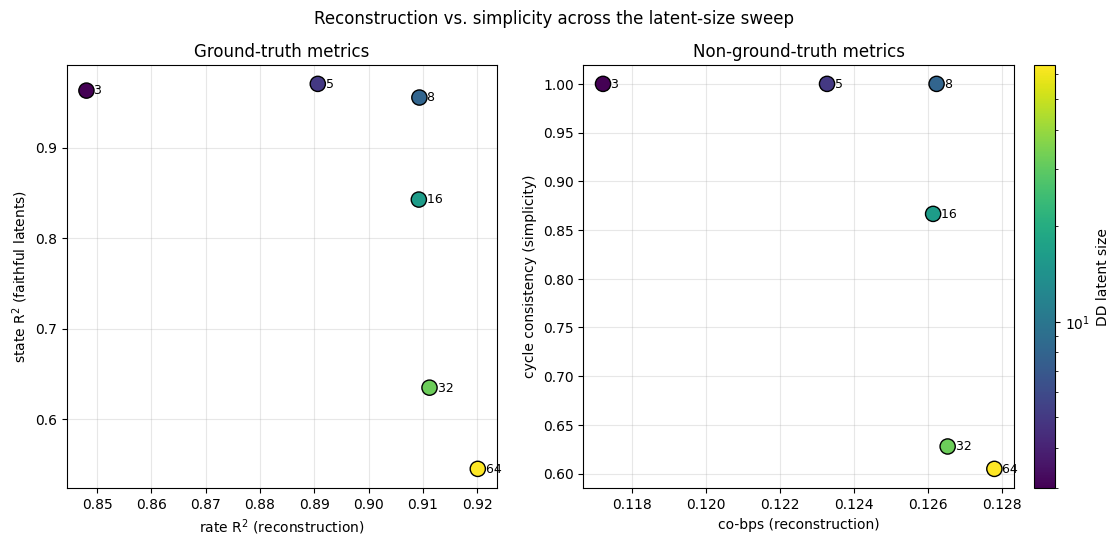

Models that 'invent features' (large latent size) push RIGHT (good reconstruction)
but DOWN (low simplicity / faithfulness) in both panels — high recon does not imply
a simple, correct model, and the non-ground-truth panel reveals the same trend.


In [10]:
import matplotlib as mpl

ls_arr = np.array(lat_sizes, dtype=float)
norm = mpl.colors.LogNorm(vmin=ls_arr.min(), vmax=ls_arr.max())
cmap = plt.cm.viridis

# x-axis = reconstruction quality, y-axis = "simplicity" of the recovered model.
panels = [
    ("Ground-truth metrics", "rate_r2", "rate R$^2$ (reconstruction)",
     "state_r2", "state R$^2$ (faithful latents)"),
    ("Non-ground-truth metrics", "co-bps", "co-bps (reconstruction)",
     "cycle_con", "cycle consistency (simplicity)"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (title, xkey, xlab, ykey, ylab) in zip(axes, panels):
    x = np.array(m[xkey], dtype=float)
    y = np.array(m[ykey], dtype=float)
    sc = ax.scatter(x, y, c=ls_arr, cmap=cmap, norm=norm, s=120, edgecolor="k", zorder=3)
    for xi, yi, ls in zip(x, y, lat_sizes):
        ax.annotate(f"  {ls}", (xi, yi), fontsize=9, va="center")
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.grid(alpha=0.3)

cbar = fig.colorbar(sc, ax=axes, fraction=0.04, pad=0.02)
cbar.set_label("DD latent size")
fig.suptitle("Reconstruction vs. simplicity across the latent-size sweep")
plt.show()

print("Models that 'invent features' (large latent size) push RIGHT (good reconstruction)")
print("but DOWN (low simplicity / faithfulness) in both panels — high recon does not imply")
print("a simple, correct model, and the non-ground-truth panel reveals the same trend.")

## 8. The input-inference / non-identifiability problem

3BFF has *external inputs* (the pulses). A realistic DD model must **infer** those inputs at the same
time as the dynamics. This creates a fundamental ambiguity: the model can explain the observed spikes
either by learning the **right dynamics driven by the right inputs**, or by **inventing inputs** that
do the work the dynamics should do. Both reconstruct the spikes — they are **non-identifiable** from
reconstruction quality alone.

To see this, we load an LFADS sweep (trained on simulated 3BFF spikes) and score:

- `co-bps` — held-out-neuron spike reconstruction (the metric you'd have without ground truth)
- `input_r2` — how well the *inferred* inputs match the *true* inputs (needs ground truth)

If `co-bps` and `input_r2` were redundant, good reconstruction would imply correct inputs. We'll see
they are **not** — models with nearly identical `co-bps` span a wide range of `input_r2`.

In [11]:
cmp_inf = Comparison(comparison_tag="input_inf")
cmp_inf.load_analysis(Analysis_TT(run_name="TT", filepath=PATH_TT), reference_analysis=True)

# Subsample the 30-model sweep to seed=0 (one model per kl_co_scale prior strength).
kl_scales = []
inf_subs = sorted(p for p in Path(PATH_INPUTINF).glob("*seed=0*") if p.is_dir())
for sub in inf_subs:
    kl = float(sub.name.split("kl_co_scale=")[1].split("_")[0])
    an = Analysis_DD.create(run_name=f"LFADS_kl={kl:g}", filepath=str(sub) + "/", model_type="LFADS")
    cmp_inf.load_analysis(an, group=f"kl={kl:g}")
    kl_scales.append(kl)
cmp_inf.regroup()
print("KL/CO prior strengths loaded:", sorted(kl_scales))

mi = cmp_inf.compute_metrics(metric_dict_list={
    "co-bps": {},"rate_r2": {}, "input_r2": {}, "cycle_con": {"variance_threshold": 0.01},
})

# IMPORTANT: regroup() can reorder comparison.analyses, so derive everything from the
# metric result's run_name list (guaranteed aligned with the metric arrays below).
run_names = mi["run_name"]
kl_scales = np.array([float(rn.split("kl=")[1]) for rn in run_names])
cobps = np.array(mi["co-bps"], dtype=float)
rates_r2 = np.array(mi["rate_r2"], dtype=float)
inpr2 = np.array(mi["input_r2"], dtype=float)

/Users/chrisversteeg/Documents/Github/ctdTest/ComputationThroughDynamicsToolkit/ctd/comparison/analysis/dd/dd.py:53: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  self.datamodule = CPU_Unpickler(f).load()


KL/CO prior strengths loaded: [0.0, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
[compute_metrics] skipping reference analysis 1/7: TT
[compute_metrics] 2/7: LFADS_kl=0 — fetching model outputs
[compute_metrics]   model-output fetch in 11.5s (train latents: (800, 500, 128), val latents: (200, 500, 128))
    CO-BPS: 0.12796525657176971
[compute_metrics]   co-bps                 in 0.1s
    Rate R2: 0.8914178609848022
[compute_metrics]   rate_r2                in 0.0s
    Input R2: 0.035645920783281326
[compute_metrics]   input_r2               in 11.0s
    Cycle Consistency R2: 0.9404134750366211
[compute_metrics]   cycle_con              in 1.5s
[compute_metrics] LFADS_kl=0 total: 24.2s
[compute_metrics] 3/7: LFADS_kl=0.0001 — fetching model outputs
[compute_metrics]   model-output fetch in 14.8s (train latents: (800, 500, 128), val latents: (200, 500, 128))
    CO-BPS: 0.12464304268360138
[compute_metrics]   co-bps                 in 0.2s
    Rate R2: 0.8887215852737427
[compute_metrics]   rate

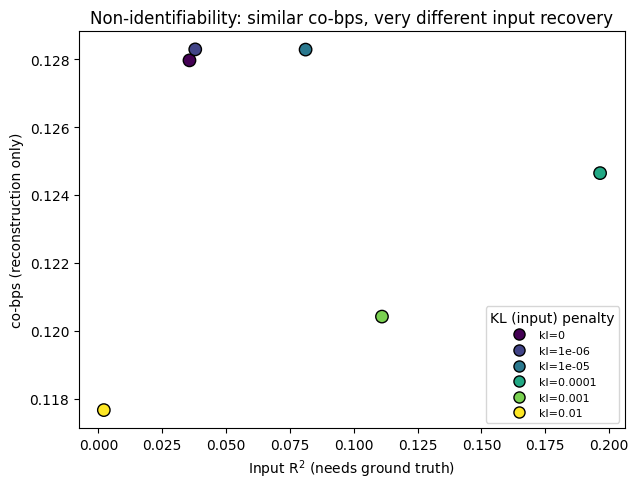

co-bps spread: 0.011 | input_r2 spread: 0.194


In [12]:
from matplotlib.lines import Line2D

# Color each model by its KL (input) penalty. Map the sorted unique KL values onto the
# colormap so darker/brighter steps = stronger penalty, and build a discrete legend.
uniq_kl = np.array(sorted(set(kl_scales.tolist())))
cmap = plt.cm.viridis
def kl_color(k):
    rank = int(np.where(uniq_kl == k)[0][0])
    return cmap(rank / max(1, len(uniq_kl) - 1))

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(inpr2, cobps, s=80, c=[kl_color(k) for k in kl_scales], edgecolor="k", zorder=3)
ax.set_xlabel("Input R$^2$ (needs ground truth)")
ax.set_ylabel("co-bps (reconstruction only)")
ax.set_title("Non-identifiability: similar co-bps, very different input recovery")

handles = [Line2D([0], [0], marker="o", linestyle="", markerfacecolor=kl_color(k),
                  markeredgecolor="k", markersize=8, label=f"kl={k:g}") for k in uniq_kl]
ax.legend(handles=handles, title="KL (input) penalty", fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()
print("co-bps spread:", round(cobps.max()-cobps.min(), 3),
      "| input_r2 spread:", round(inpr2.max()-inpr2.min(), 3))

## 9. Priors dramatically change the inferred dynamics

The escape from non-identifiability is a **prior**. In LFADS the `kl_co_scale` (the
KL weight on the inferred *controller outputs* / inputs) penalizes how much the model is allowed to
"explain away" the data with inferred inputs. A stronger prior tends to force the explanation into the
**dynamics** instead — which is what we want for 3BFF, where the dynamics are the computation. The
relationship is not perfectly monotonic, so below we let the *measured* `input_r2` decide which model
is good vs bad.

This is the story of `make_figure6_combined.py`. Below we:

1. show `input_r2` as a function of the prior strength `kl_co_scale`, and
2. compare the **recovered fixed-point structure** of the model with the **lowest** vs **highest**
   measured `input_r2` — the high-`input_r2` model recovers the cube, the low one does not.

Fixed points for a DD model are found at its **mean inferred input**, following the Figure-6 recipe.

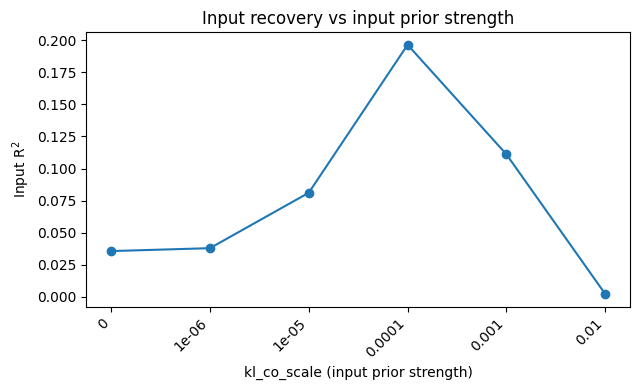

bad  (lowest  input_r2): kl=0, input_r2=0.036
good (highest input_r2): kl=0.0001, input_r2=0.196


In [13]:
# input_r2 vs prior strength
order = np.argsort(kl_scales)
ks = np.array(kl_scales)[order]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(np.arange(len(ks)), inpr2[order], "o-")
ax.set_xticks(np.arange(len(ks)))
ax.set_xticklabels([f"{k:g}" for k in ks], rotation=45, ha="right")
ax.set_xlabel("kl_co_scale (input prior strength)")
ax.set_ylabel("Input R$^2$")
ax.set_title("Input recovery vs input prior strength")
fig.tight_layout()
plt.show()

# Pick "good"/"bad" by the ACTUAL input_r2, not by prior strength (a stronger KL
# prior does not guarantee better input recovery).
good_idx = int(np.argmax(inpr2))
bad_idx = int(order[0])
print(f"bad  (lowest  input_r2): kl={kl_scales[bad_idx]:g}, input_r2={inpr2[bad_idx]:.3f}")
print(f"good (highest input_r2): kl={kl_scales[good_idx]:g}, input_r2={inpr2[good_idx]:.3f}")

  iter 10000/10000  q=2.04E-05+/-5.64E-05  dq=1.18E-08+/-4.41E-08
  Maximum iteration count reached. Terminating.

Found 512 unique fixed points.
Decomposing Jacobians in a single batch.
Sorting by Eigenvalue magnitude.
  iter 10000/10000  q=3.69E-06+/-3.02E-05  dq=6.00E-09+/-3.20E-08
  Maximum iteration count reached. Terminating.

Found 512 unique fixed points.
Decomposing Jacobians in a single batch.
Sorting by Eigenvalue magnitude.


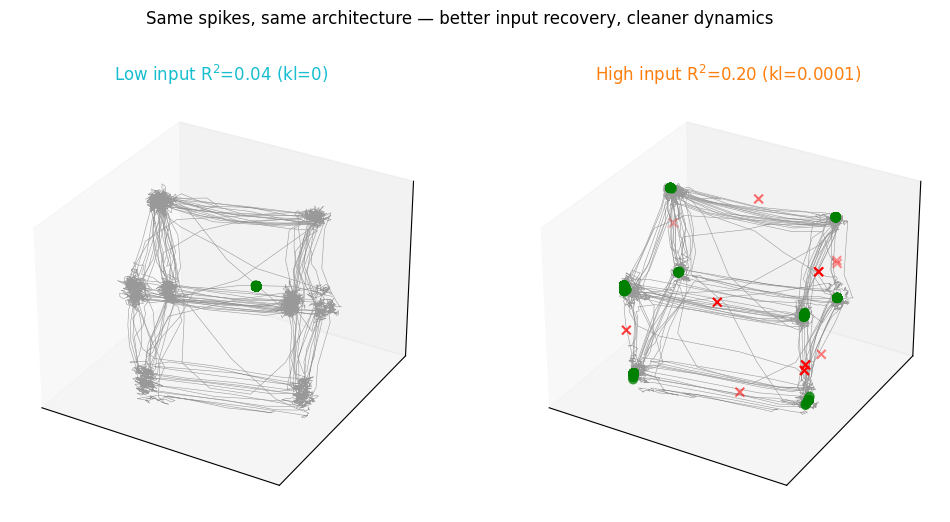

In [14]:
# DD analyses, in the same order metrics were computed (skip the TT reference at index 0).
dd_list = [a for a in cmp_inf.analyses if isinstance(a, Analysis_DD)]

def dd_fixed_points(analysis, n_inits=512):
    """Find FPs at the model's mean inferred input (make_figure6 recipe)."""
    inp = analysis.get_inferred_inputs(phase="val")
    mean_in = torch.mean(inp, dim=0).mean(dim=0).detach()
    fps = analysis.compute_FPs(inputs=mean_in, n_inits=n_inits, device="cpu",
                               seed=0, compute_jacobians=True)
    _, lats = analysis.get_model_outputs(phase="val")
    return fps, lats.detach().cpu().numpy()

def plot_dd_fps(ax, fps, lats, q_thresh=1e-5, title="", color="k"):
    keep = fps.qstar < q_thresh
    xs = fps.xstar[keep]
    stab = fps.is_stable[keep]
    pca = PCA(n_components=3)
    lp = pca.fit_transform(lats.reshape(-1, lats.shape[-1])).reshape(lats.shape[0], lats.shape[1], 3)
    xp = pca.transform(xs)
    for i in range(min(10, lp.shape[0])):
        ax.plot(lp[i, :, 0], lp[i, :, 1], lp[i, :, 2], lw=0.4, color="0.6")
    ax.scatter(xp[stab, 0], xp[stab, 1], xp[stab, 2], c="g", marker="o", s=40)
    ax.scatter(xp[~stab, 0], xp[~stab, 1], xp[~stab, 2], c="r", marker="x", s=40)
    ax.set_title(title, color=color)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

fps_bad, lats_bad = dd_fixed_points(dd_list[bad_idx])
fps_good, lats_good = dd_fixed_points(dd_list[good_idx])

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection="3d")
plot_dd_fps(ax1, fps_bad, lats_bad,
            title=f"Low input R$^2$={inpr2[bad_idx]:.2f} (kl={kl_scales[bad_idx]:g})",
            color="tab:cyan")
ax2 = fig.add_subplot(122, projection="3d")
plot_dd_fps(ax2, fps_good, lats_good,
            title=f"High input R$^2$={inpr2[good_idx]:.2f} (kl={kl_scales[good_idx]:g})",
            color="tab:orange")
fig.suptitle("Same spikes, same architecture — better input recovery, cleaner dynamics")
plt.show()

## 10. Conclusion

The thread through this notebook:

- **Computation is dynamics.** For 3BFF, the *algorithm* is literally the fixed-point structure —
  8 stable corner-memories plus the saddles that route bit-flips (Sections 2 & 4).
- **We never see the dynamics**; we see spikes (Section 5), simulated here from a task-trained teacher
  so we have ground truth (Section 6).
- **Inference can fail.** Too little capacity underfits; too much **invents features** that inflate
  reconstruction while corrupting the recovered latents (Section 7).
- **Inputs make it worse.** When a model infers its own inputs, the dynamics become **non-identifiable** — we cannot distinguish models with accurate dynamics from those that explain the data with invented inputs (Section 8).
- **Priors are important presures for accurate dynamical inference.** A prior on inferred inputs (`kl_co_scale`) pushes the explanation back into
  the dynamics, dramatically improving input recovery *and* restoring the correct fixed-point
  structure (Section 9).

The practical lesson: **reconstruction metrics alone do not validate inferred dynamics.** Ground-truth
benchmarks like 3BFF — where the true fixed-point algorithm is known — are what let us measure whether
a data-driven model recovered the computation or merely fit the spikes.

For the full publication-quality versions of these analyses, see
`examples/figures/Fig3TaskPerformance/make_figure3_task_performance.py` (TT fixed points) and
`examples/figures/Fig6InputInf/make_figure6_combined.py` (input inference & priors).

## 11. Case study — finding fixed points in a MultiTask network

The 3BFF network had one job, so its fixed points formed a single cube-like memory
structure. Real cognitive tasks reuse dynamical motifs across contexts. In this case
study you will investigate one such motif in the **MultiTask** environment
([task_env/multitask.py](../ctd/task_modeling/task_env/multitask.py)), a single RNN
trained on 15 interval, memory, decision, and response tasks from the Yang-2019 suite
used by Driscoll et al. 2024.

We will focus on **MemoryPro**. On each trial the network should:

1. keep fixation during the context period,
2. observe a stimulus angle during `stim1`,
3. remember that angle during `mem1`, and
4. report the remembered angle during `response`.

Your goal is to work out how to find and interpret fixed points for this task. By the
end, you should be able to answer:

- What input should be held constant when looking for fixed points in a task phase?
- Which latent states make good initial conditions for fixed-point optimization?
- How do `qstar` and `is_stable` help you decide which candidate points to trust?
- How can the readout and a PCA projection make the fixed points interpretable?

> **Answers notebook.** A completed version of the original case study has been moved
> to `examples/CtDToolkit_Walkthrough_Answers.ipynb`. Use it only after you have tried
> the investigation here.

> **Assets.** Unlike Sections 1–10, this section loads the full pretrained MultiTask
> model under `content/trained_models/task-trained/tt_MultiTask/`. Fixed-point finding
> can take a few minutes on CPU, so start with small `n_inits` while developing.


In [15]:
import torch
from matplotlib.colors import hsv_to_rgb
from matplotlib.lines import Line2D
from ctd.comparison.analysis.tt.tasks.tt_MultiTask import Analysis_TT_MultiTask
from ctd.comparison.fixedpoints import find_fixed_points

PATH_MT = HOME_DIR + "pretrained/20241113_MultiTask_NoisyGRU_Final2/"
TASK = "MemoryPro"

mt = Analysis_TT_MultiTask(run_name="MT_MemoryPro", filepath=PATH_MT)
readout = mt.wrapper.model.readout      # latent -> [fixation, cos, sin]
cell = mt.wrapper.model.cell            # recurrent update F(input, state)

# get_task_flag returns which validation trials are MemoryPro trials and a
# per-trial dictionary of phase -> [start, end] indices.
task_flag, phase_task = mt.get_task_flag(TASK, phase="val")
fl = np.array(task_flag)
true_inputs = mt.get_true_inputs(phase="val")[fl].detach().numpy()
lat = mt.get_latents_noiseless(phase="val")[fl].detach().numpy()
out = mt.get_model_outputs_noiseless(phase="val")["controlled"][fl].detach().numpy()
n_tr = int(fl.sum())

print(f"{n_tr} {TASK} trials")
print(f"phases: {list(phase_task[0].keys())}")
print(f"latent shape: {lat.shape}; input shape: {true_inputs.shape}; output shape: {out.shape}")


94 MemoryPro trials
phases: ['context', 'stim1', 'mem1', 'response']
latent shape: (94, 320, 128); input shape: (94, 320, 20); output shape: (94, 320, 3)


### 11a. Method toolbox: phases, inputs, initial states, and projections

A fixed point is always defined relative to an input. For a task-trained RNN, the
question is not just "where does the state stop?" but "where does the state stop
under this task-phase input?"

Useful ingredients:

- **Phase windows**: `phase_task[i]["mem1"]` gives the `[start, end]` bins for trial `i`.
- **Initial states**: latent states from the phase you care about are usually good
  initial conditions for fixed-point optimization.
- **Held input**: use a representative input vector from the phase, or sweep a
  controlled input such as stimulus angle.
- **Convergence speed**: `fps.qstar` is the squared speed at the candidate fixed point;
  smaller is better.
- **Stability**: `fps.is_stable == 1` marks locally attracting fixed points.
- **Interpretability**: project latent fixed points into a low-dimensional PCA space,
  then compare them to the model readout.


In [16]:
def phase_slice(arr, trial_idx, phase_name):
    """Return arr[trial_idx] restricted to one named task phase."""
    s, e = phase_task[trial_idx][phase_name]
    return arr[trial_idx, s:e]


def collect_phase_latents(phase_name):
    """Stack latent states from the selected phase across all MemoryPro trials."""
    return np.concatenate(
        [phase_slice(lat, i, phase_name) for i in range(n_tr)],
        axis=0,
    )


def phase_input_template(trial_idx, phase_name):
    """Use the first bin of a phase as a representative held input."""
    s, _ = phase_task[trial_idx][phase_name]
    return true_inputs[trial_idx, s].copy()


def angle_colors(theta):
    """Map angles to circular HSV colors."""
    theta = np.asarray(theta, dtype=float)
    hue = (theta % (2 * np.pi)) / (2 * np.pi)
    return hsv_to_rgb(np.column_stack([hue, np.ones_like(hue), np.ones_like(hue)]))


# Build a common visualization space from memory-period activity.
# TODO: Try changing this to "stim1" or "response" later. What changes?
projection_phase = "mem1"
projection_latents = collect_phase_latents(projection_phase)
pca = PCA(n_components=3).fit(projection_latents)


def project_for_plot(x):
    """Project latents into [PC1, PC2, readout-y] for visualization."""
    x = np.asarray(x)
    y = readout(torch.tensor(x, dtype=torch.float32)).detach().numpy()
    return np.column_stack([pca.transform(x)[:, :2], y[:, 2]])


### 11b. Warm-up: inspect one MemoryPro trial

Before finding fixed points, inspect the task timing. Identify which input dimensions
are fixation, stimulus cosine, stimulus sine, and task context. Then ask: which of
these should be held constant during `mem1`? Which should be held constant during
`response`?


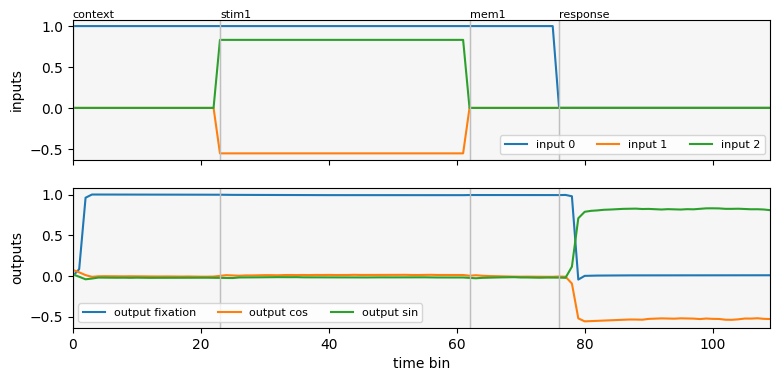

In [42]:
trial_idx = 0
fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)

axes[0].plot(true_inputs[trial_idx, :, 0], label="input 0")
axes[0].plot(true_inputs[trial_idx, :, 1], label="input 1")
axes[0].plot(true_inputs[trial_idx, :, 2], label="input 2")
axes[1].plot(out[trial_idx, :, 0], label="output fixation")
axes[1].plot(out[trial_idx, :, 1], label="output cos")
axes[1].plot(out[trial_idx, :, 2], label="output sin")
ind_end = phase_task[trial_idx]["response"][1]

for phase_name, (s, e) in phase_task[trial_idx].items():
    for ax in axes:
        ax.axvspan(s, e, color="0.9", alpha=0.35)
        ax.axvline(s, color="0.75", lw=1)
    axes[0].text(s, axes[0].get_ylim()[1], phase_name, fontsize=8, va="bottom")

axes[0].set_ylabel("inputs")
axes[1].set_ylabel("outputs")
axes[1].set_xlabel("time bin")
axes[0].legend(fontsize=8, ncol=3)
axes[1].legend(fontsize=8, ncol=3)
axes[0].set_xlim(0, ind_end)
axes[1].set_xlim(0, ind_end)

plt.show()

# TODO: Write down which phase you want to analyze first and why.


### 11c. Exercise: find memory-period fixed points

Start with the memory period. During `mem1`, the stimulus is gone but fixation and
task context remain active. A good first fixed-point search uses:

- initial states sampled from `mem1` latents,
- a representative held `mem1` input,
- a conservative `qstar` threshold, and
- stability labels to separate attracting points from saddles.

You will call `find_fixed_points` directly — there is no shortcut helper here. Build
the three ingredients it needs yourself, using the toolbox above:

- `state_trajs`: a bank of candidate initial states. Try `collect_phase_latents(PHASE)`.
- `inputs`: the input held constant during the search. Try
  `phase_input_template(trial_idx, PHASE)` for a single representative input (it will
  be broadcast to every initial state), or build a `[n_inits, input_dim]` array if you
  want a different input per candidate.
- `model`: the state-update function whose fixed points you want — this is just
  `cell`, already extracted from the network above.

In [ ]:
PHASE = "mem1"
N_INITS = 250          # increase after the code works
Q_THRESH = 5e-5

# TODO: Build the ingredients `find_fixed_points` needs.
#   - state_trajs: candidate initial states, e.g. collect_phase_latents(PHASE)
#   - inputs: the input to hold constant, e.g. phase_input_template(trial_idx=0, phase_name=PHASE)
state_trajs = None  # TODO
inputs = None  # TODO
assert state_trajs is not None and inputs is not None, "Fill in state_trajs and inputs above."

fps_mem = find_fixed_points(
    model=cell,
    state_trajs=torch.tensor(state_trajs, dtype=torch.float32),
    inputs=torch.tensor(inputs, dtype=torch.float32),
    n_inits=N_INITS,
    noise_scale=0.0,
    learning_rate=5e-3,
    max_iters=10000,
    device="cpu",
    seed=0,
    compute_jacobians=True,
)

# TODO: Inspect fps_mem. How many candidates were found? How many have small qstar?
q_good = fps_mem.qstar < Q_THRESH
print(f"candidate fixed points: {len(fps_mem.xstar)}")
print(f"qstar < {Q_THRESH}: {q_good.sum()}")

x_mem = fps_mem.xstar[q_good]
z_mem = project_for_plot(x_mem)

# TODO: What happens if Q_THRESH is stricter?

### 11d. Exercise: visualize the memory fixed points

A useful visualization should show whether fixed points form a discrete set, a line,
a ring, or something messier. Overlay actual trajectories from the same phase to see
whether the optimizer found points on the part of state space the model actually uses.


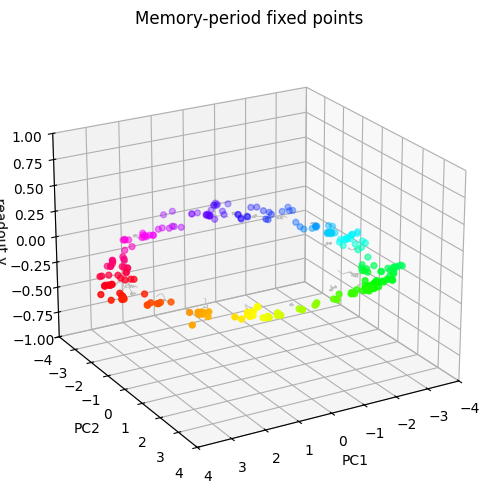

In [44]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

# Plot a subset of memory-period trajectories.
for i in range(0, n_tr, max(1, n_tr // 20)):
    traj = project_for_plot(phase_slice(lat, i, PHASE))
    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color="0.75", lw=0.6)

# Color fixed points by angle in the PCA plane.
fp_angle = np.arctan2(z_mem[:, 1], z_mem[:, 0])
ax.scatter(z_mem[:, 0], z_mem[:, 1], z_mem[:, 2], c=angle_colors(fp_angle), s=18)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("readout y")
ax.set_title("Memory-period fixed points")
ax.view_init(22, 60)
ax.set_xlim([-4, 4]); ax.set_ylim([-4, 4]); ax.set_zlim([-1, 1])
plt.show()

# TODO: Describe the geometry you see. Is it more cube-like, line-like, or ring-like?


### 11e. Challenge: compare phases and stimulus-selected fixed points

Now design your own fixed-point analyses.

Suggested investigations:

1. **Response phase**: repeat the analysis for `PHASE = "response"`. Project the fixed
   points through `readout`. Do they form a circle in output `(cos, sin)` space?
2. **Stimulus sweep**: hold the `stim1` input at different angles
   `theta = np.linspace(0, 2*np.pi, ...)`, run `find_fixed_points`, and ask whether
   the selected stable point moves around the memory ring.
3. **Input dependence**: compare fixed points found with `mem1`, `stim1`, and
   `response` held inputs. Which parts of the fixed-point landscape are shared, and
   which are reshaped by the task input?
4. **Robustness**: vary `n_inits`, `noise_scale`, `Q_THRESH`, and `max_iters`. Which
   conclusions survive these choices?

Keep a short lab note for each run: held input, initial states, number of low-`qstar`
points, number of stable points, and the geometry you observe.


In [ ]:
# Challenge workspace.
# Copy/adapt the cells above here instead of editing your working solution away.

# Example starting point for a response-phase analysis:
PHASE = "response"
# state_trajs_resp = collect_phase_latents(PHASE)
# inputs_resp = phase_input_template(trial_idx=0, phase_name=PHASE)
# fps_resp = find_fixed_points(
#     model=cell,
#     state_trajs=torch.tensor(state_trajs_resp, dtype=torch.float32),
#     inputs=torch.tensor(inputs_resp, dtype=torch.float32),
#     n_inits=250,
#     noise_scale=0.0,
#     learning_rate=5e-3,
#     max_iters=10000,
#     device="cpu",
#     seed=0,
#     compute_jacobians=True,
# )
# x_resp = fps_resp.xstar[fps_resp.qstar < Q_THRESH]
# y_resp = readout(torch.tensor(x_resp, dtype=torch.float32)).detach().numpy()
# plt.scatter(y_resp[:, 1], y_resp[:, 2])

# Example starting point for an explicit held-input search:
# init_states = collect_phase_latents("stim1")
# held_input = phase_input_template(trial_idx=0, phase_name="stim1")
# held_input[1] = np.cos(theta)
# held_input[2] = np.sin(theta)
# fps = find_fixed_points(
#     model=cell,
#     state_trajs=torch.tensor(init_states, dtype=torch.float32),
#     inputs=torch.tensor(held_input, dtype=torch.float32),
#     n_inits=250,
#     noise_scale=0.0,
#     learning_rate=2e-2,
#     max_iters=4000,
#     device="cpu",
#     seed=0,
#     compute_jacobians=True,
# )

## Appendix: the rest of the CtD dataset suite

We used the **3-bit flip-flop (NBFF)** throughout because its algorithm — 8 corner attractors plus
saddles — is so clean. But CtD ships several other synthetic benchmarks, each stressing a different
aspect of computation-through-dynamics. They all plug into the *same* machinery: a `task_env`
(`ctd/task_modeling/task_env/`), a hydra config (`configs/env_task/<Task>.yaml`), and a pretrained
task-trained model under `content/trained_models/task-trained/tt_<Task>/`.

Below is a short rundown of each, followed by a cell showing how to load any of them.

### A.1 NBFF — N-bit flip-flop *(our running example)*

`NBitFlipFlop` ([task_env/task_env.py](../ctd/task_modeling/task_env/task_env.py)). An
extension of the classic 3-bit flip-flop: `n` independent memory bits, each toggled by $\pm 1$
impulses. The canonical solution is $2^n$ stable fixed points (cube corners for `n=3`) joined by
saddles. The cleanest setting for *seeing* an algorithm in the fixed-point structure, and for
benchmarking how faithfully data-driven models recover it. Pretrained: `tt_3bff`.

### A.2 MultiTask — 15 cognitive tasks in one network

`MultiTask` ([task_env/multitask.py](../ctd/task_modeling/task_env/multitask.py)). A reimplementation
of the Yang / Driscoll paradigm: a single RNN performs 15 simple cognitive tasks (memory-pro/anti,
decision-making, delayed comparisons, etc.) selected by rule inputs. The scientific question is
**compositionality** — how the network reuses shared *dynamical motifs* (e.g. memory rings, decision
saddles) across tasks. Fixed-point analysis here is done *per task phase* (see
`compute_fps_phase` and `make_figure3` Panel F). Pretrained: `tt_MultiTask`.

### A.3 RandomTarget — a delayed reach with real biomechanics

`RandomTarget` ([task_env/random_target.py](../ctd/task_modeling/task_env/random_target.py)). A
musculoskeletal control task built on **MotorNet** (Codol et al.): the network drives a 2-joint,
6-muscle arm to reach random targets after a variable delay, and must cope with mid-reach
perturbations ("bumps"). Unlike the cognitive tasks, the dynamics are coupled to a physical plant, so
analysis emphasizes motor-potent vs motor-null structure and how perturbations are corrected (see
`make_figure3` Panels G–I). Pretrained: `tt_RandomTarget` (requires the `motornet` package).

### A.4 PhaseCodedMemory — memory in the *phase* of an oscillation

`PhaseCodedMemory` ([task_env/phase_coded_memory.py](../ctd/task_modeling/task_env/phase_coded_memory.py)).
A working-memory benchmark where the remembered quantity is stored as a **cue-dependent phase shift**
of an ongoing oscillation rather than a static attractor. This stresses *limit-cycle* dynamics and is
a harder target for data-driven models (it features prominently in the input-inference / priors story,
Figs 5–6). Pretrained: `tt_PhaseCodedMemory`.

### A.5 ChaoticDelayedMatching — computation amid chaos

`ChaoticDelayedMatching` ([task_env/chaotic_delayed_matching.py](../ctd/task_modeling/task_env/chaotic_delayed_matching.py)).
A delayed non-match-to-sample task whose teacher is a simple **chaotic (or near-chaotic) rate-RNN**.
The cue computation must survive being embedded in weakly-to-moderately chaotic latent dynamics,
making it a stress test for Lyapunov-spectrum / stability analyses (`compute_lyapunov_spectrum`) and
for whether inferred models recover the right *degree* of chaos. Pretrained:
`tt_ChaoticDelayedMatching`.

### Loading any of the datasets

Every task above ships a pretrained task-trained model. Most load with the base `Analysis_TT`;
**MultiTask** and **RandomTarget** have task-specific subclasses that add task-aware helpers (phase
flags, the MotorNet plant, etc.). Once loaded, the *same* analysis and comparison tools used in this
notebook — `get_latents`, `compute_FPs` / `plot_fps`, `compute_lyapunov_spectrum`, and the
`Comparison` object — apply unchanged.

In [21]:
# Pretrained task-trained models that ship with CtD.
tt_root = Path(HOME_DIR) / "content" / "trained_models" / "task-trained"
available = sorted(p.name for p in tt_root.glob("tt_*") if (p / "model.pkl").exists())
print("Available pretrained task-trained models:")
for name in available:
    print("   ", name)

# Which analysis class to use for each task:
print("\nLoaders:")
print("  NBFF / PhaseCodedMemory / ChaoticDelayedMatching -> Analysis_TT")
print("  MultiTask    -> tt.tasks.tt_MultiTask.Analysis_TT_MultiTask")
print("  RandomTarget -> tt.tasks.tt_RandomTarget.Analysis_TT_RandomTarget  (needs motornet)")

# Example: load the MultiTask teacher and run the same FP machinery on it.
mt_path = str(tt_root / "tt_MultiTask") + "/"
if Path(mt_path + "model.pkl").exists():
    try:
        from ctd.comparison.analysis.tt.tasks.tt_MultiTask import Analysis_TT_MultiTask
        an_mt = Analysis_TT_MultiTask(run_name="MultiTask", filepath=mt_path)
        print(f"\nLoaded MultiTask via {type(an_mt).__name__}: "
              f"{an_mt.n_trials} trials, latent dim {an_mt.get_latents(phase='val').shape[-1]}")
    except Exception as e:
        print(f"\n(MultiTask load skipped: {e})")
else:
    print("\n(tt_MultiTask not found on disk — generate it or download the pretrained models.)")

Available pretrained task-trained models:
    tt_3bff
    tt_ChaoticDelayedMatching
    tt_MultiTask
    tt_PhaseCodedMemory
    tt_RandomTarget

Loaders:
  NBFF / PhaseCodedMemory / ChaoticDelayedMatching -> Analysis_TT
  MultiTask    -> tt.tasks.tt_MultiTask.Analysis_TT_MultiTask
  RandomTarget -> tt.tasks.tt_RandomTarget.Analysis_TT_RandomTarget  (needs motornet)

Loaded MultiTask via Analysis_TT_MultiTask: 7500 trials, latent dim 128
